### Import the Datasets

In [1]:
from datasets import load_dataset

/Users/vinod/Desktop/github_repos/LLM_fine_tuning/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
dataset = load_dataset("dair-ai/emotion")

In [3]:
dataset.keys()

dict_keys(['train', 'validation', 'test'])

In [4]:
dataset['train']['text']

Column(['i didnt feel humiliated', 'i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake', 'im grabbing a minute to post i feel greedy wrong', 'i am ever feeling nostalgic about the fireplace i will know that it is still on the property', 'i am feeling grouchy', ...])

## Explore the dataset

In [5]:
df = dataset['train'].to_pandas()

In [6]:
df

,text,label
0,i didnt feel humiliated,0
1,i can go from feeling so hopeless to so damned...,0
2,im grabbing a minute to post i feel greedy wrong,3
3,i am ever feeling nostalgic about the fireplac...,2
4,i am feeling grouchy,3
...,...,...
15995,i just had a very brief time in the beanbag an...,0
15996,i am now turning and i feel pathetic that i am...,0
15997,i feel strong and good overall,1
15998,i feel like this was such a rude comment and i...,3


In [7]:
import matplotlib.pyplot as plt

In [8]:
label_names = dataset['train'].features['label'].names
print(label_names)

['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']


In [9]:
label_counts = df['label'].value_counts(ascending=True)
print(label_counts)

label
5     572
2    1304
4    1937
3    2159
0    4666
1    5362
Name: count, dtype: int64


In [10]:
df['label_text'] = df['label'].apply(lambda x: label_names[int(x)])

In [11]:
label_counts_text = df['label_text'].value_counts(ascending=True)

Text(0.5, 1.0, 'Total Text Classification Count based on the class')

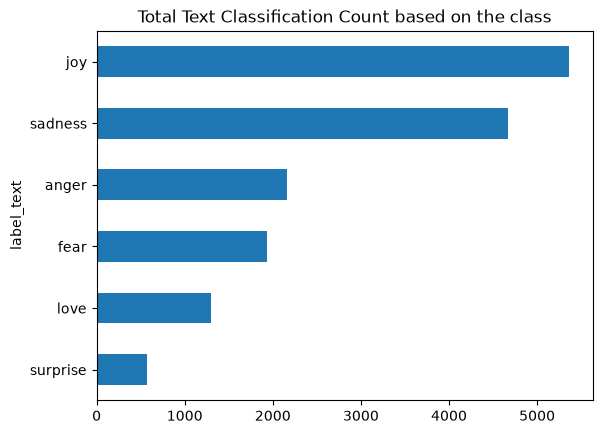

In [12]:
label_counts_text.plot.barh()
plt.title("Total Text Classification Count based on the class")

## Tokenisation of the text

In [13]:
from transformers import AutoTokenizer

In [14]:
model_checkpoint = "bert-base-uncased"

In [15]:
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

In [16]:
tokenizer("Hello, how are you?", truncation=True, max_length=15, padding="max_length")

{'input_ids': [101, 7592, 1010, 2129, 2024, 2017, 1029, 102, 0, 0, 0, 0, 0, 0, 0], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0]}

## Split the data into training, test and validation

In [17]:
from sklearn.model_selection import train_test_split

In [18]:
## Split into 70% for training, 20% for test and 10% for validation
train, test = train_test_split(df, test_size=0.3)
test, validation = train_test_split(test, test_size=1/3)

In [19]:
print(train.shape, test.shape, validation.shape)

(11200, 3) (3200, 3) (1600, 3)


In [20]:
from datasets import Dataset, DatasetDict

dataset = DatasetDict({
    'train': Dataset.from_pandas(train, preserve_index=False),
    'test': Dataset.from_pandas(test, preserve_index=False),
    'validation': Dataset.from_pandas(validation, preserve_index=False)
})

In [21]:
dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'label_text'],
        num_rows: 11200
    })
    test: Dataset({
        features: ['text', 'label', 'label_text'],
        num_rows: 3200
    })
    validation: Dataset({
        features: ['text', 'label', 'label_text'],
        num_rows: 1600
    })
})

In [22]:
dataset['train'][0]

{'text': 'i want to be able to leave my house on my own without feeling terrified and im going to work on this every day',
 'label': 4,
 'label_text': 'fear'}

### Adding tokeniser across the whole dataset

In [23]:
def tokenize(batch):
    return tokenizer(batch['text'], padding = True, truncation = True)

# tokenize(dataset['train'][:10])

In [24]:
encoded = dataset.map(tokenize, batched=True, batch_size=None)

Map: 100%|██████████| 1600/1600 [00:00<00:00, 76237.55 examples/s]


### Adding Head for Sequence Classification

In [25]:
label2id = {label:i for i, label in enumerate(label_names)}
id2label = {i:label for i, label in enumerate(label_names)}

In [26]:
from transformers import AutoModelForSequenceClassification, AutoConfig
import torch

In [27]:
if torch.has_mps:
    device = torch.device('mps')

config = AutoConfig.from_pretrained(model_checkpoint, label2id=label2id, id2label=id2label)
model = AutoModelForSequenceClassification.from_pretrained(model_checkpoint, config=config).to(device)

/var/folders/ds/zwhhf46x04s6yg7r7fy_sg980000gn/T/ipykernel_36302/3966003401.py:1: UserWarning: 'has_mps' is deprecated, please use 'torch.backends.mps.is_built()'
  if torch.has_mps:
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 7056.28it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECT

In [28]:
model

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,),

## Model Training

In [29]:
from transformers import TrainingArguments

batch_size = 64
training_dir = "bert_base_uncased_trained_model"

training_args = TrainingArguments(output_dir=training_dir, num_train_epochs=2, learning_rate =2e-5, 
                                  per_device_eval_batch_size=batch_size, per_device_train_batch_size=batch_size,
                                  weight_decay=0.01, eval_strategy='epoch', disable_tqdm=False)

## Evaluation of Model performance

In [31]:
from sklearn.metrics import accuracy_score, f1_score

In [32]:
def compute_metrics(pred):
    labels = pred.label_ids
    pred = pred.prediction.argmax(-1)

    f1 = f1_score(labels, pred, average = 'weighted')
    acc = accuracy_score(labels, preds)

    return {"accuracy": acc, "f1 score": f1}

### Trainer

In [33]:
from transformers import Trainer

In [36]:
trainer = Trainer(model = model, 
                  args = training_args, 
                  compute_metrics= compute_metrics, 
                  train_dataset = encoded['train'], 
                  eval_dataset= encoded['validation'], 
                  processing_class=tokenizer)

In [ ]:
trainer.train()

/Users/vinod/Desktop/github_repos/LLM_fine_tuning/.venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss
